# 04. PyTorch Custom Datasets

We've used some datasets with PyTorch before. How do you get your own data into PyTorch?

One of the ways to do so is via: Custom Datasets.

## Domain Libraries

Depending on what youre working on, vision, text, audio, recommendation, you'll want to look into each of the PyTorch domain libraries for existing data loading functions & customizable data loading functions.

## 0. Importing PyTorch & writing device exclusive code

In [1]:
import torch
from torch import nn


In [2]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 1. Get data

Our dataset is a subset of the Food101 dataset.

Food101 starts with 101 different classes of food & 1000 images of class (i.e 750 training & 250 testing).

Our dataset starts with 3 classes of food & only 10% of the images.

Why? 
* When starting an ML project, its best practice to start small & increase scale when necessary.
* Whole point is to speed up how fast you can experiment

In [3]:
import requests
import zipfile
from pathlib import Path

# Setup path to a data folder
### See Misc\Data\04_custstm_data_create.ipynb
image_path = Path("data/pizza_steak_sushi_10.0_percent")

## 2. Becoming one with the data (data preparation & data exploration)



In [4]:
import os

def walk_through_dir(dir_path):
    """walks through dir_path returning its contents.

    Args:
        dir_path (str): target directory

    Return:
        A print out of:
            number of subdirectories in dir_path.
            number of images (files) in each subdirectory.
            name of each subdirectory.
    """
    import os
    
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")



walk_through_dir(image_path)


There are 2 directories and 0 images in 'data\pizza_steak_sushi_10.0_percent'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi_10.0_percent\test'.
There are 0 directories and 25 images in 'data\pizza_steak_sushi_10.0_percent\test\pizza'.
There are 0 directories and 19 images in 'data\pizza_steak_sushi_10.0_percent\test\steak'.
There are 0 directories and 31 images in 'data\pizza_steak_sushi_10.0_percent\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi_10.0_percent\train'.
There are 0 directories and 78 images in 'data\pizza_steak_sushi_10.0_percent\train\pizza'.
There are 0 directories and 75 images in 'data\pizza_steak_sushi_10.0_percent\train\steak'.
There are 0 directories and 72 images in 'data\pizza_steak_sushi_10.0_percent\train\sushi'.


In [5]:
# Setup train & test paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(WindowsPath('data/pizza_steak_sushi_10.0_percent/train'),
 WindowsPath('data/pizza_steak_sushi_10.0_percent/test'))

### 2.1 Visualizing an image

Write code to:
1. Get all of the image paths
2. Pick a random image path using Python's random.choice()
3. Get the image class name using `pathlib.Path.parent.stem`
4. Since we're working with images, let's open the image with Python's PIL
5. Show image & print metadata

In [6]:
image_path

WindowsPath('data/pizza_steak_sushi_10.0_percent')

Random image path: data\pizza_steak_sushi_10.0_percent\train\sushi\3107839.jpg
Image class: sushi
Image height * width: 384 * 512


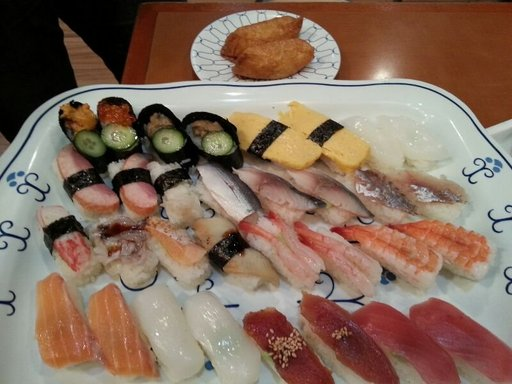

In [7]:
import random
from PIL import Image

# Set random seed
random.seed(1337)

# 1. Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg")) # Get all under pizza_steak_sushi_10.0_percent/get all under test and trai/ get all under pizza, steak, sushi that ends in .jpg
image_path_list

# 2. Pick a random image path
random_image_path = random.choice(image_path_list)
#print(random_image_path)

# 3. Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem
#print(image_class)

# 4. Open image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height * width: {img.height} * {img.width}")
img

Image size: (384, 512, 3)


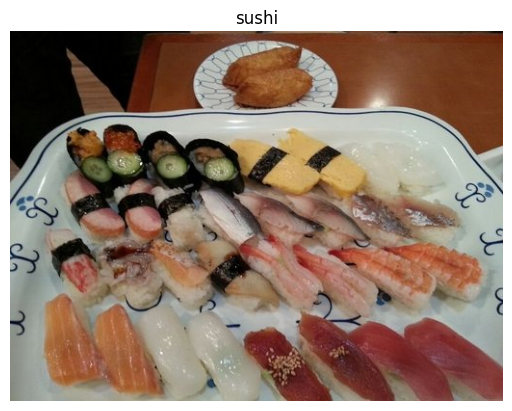

In [8]:
from matplotlib import pyplot as plt
import numpy as np

# Convert image to numpy array for plotting
img_np = np.asarray(img) 

# Plot the image
plt.imshow(img_np)
plt.title(f"{image_class}")
plt.axis(False)
print(f"Image size: {img_np.shape}") # (height, width, color channels) # if left as tensorm it would only show height and width

In [9]:
img_np

array([[[  4,   4,   2],
        [  4,   4,   2],
        [  4,   4,   2],
        ...,
        [ 15,   2,   0],
        [ 18,   5,   0],
        [ 20,   7,   0]],

       [[  2,   2,   0],
        [  2,   2,   0],
        [  3,   3,   1],
        ...,
        [ 22,   4,   0],
        [ 25,   6,   0],
        [ 27,   9,   0]],

       [[  2,   2,   0],
        [  2,   2,   0],
        [  2,   2,   0],
        ...,
        [ 59,  31,  19],
        [ 61,  31,  21],
        [ 63,  33,  22]],

       ...,

       [[130, 137, 121],
        [130, 137, 121],
        [132, 138, 124],
        ...,
        [140,  90,  83],
        [139,  88,  84],
        [139,  88,  84]],

       [[130, 137, 121],
        [131, 138, 122],
        [132, 139, 123],
        ...,
        [146,  99,  91],
        [144,  99,  93],
        [144,  99,  93]],

       [[131, 138, 122],
        [131, 138, 122],
        [133, 140, 124],
        ...,
        [152, 108,  99],
        [151, 108, 101],
        [152, 109, 102]]

## 3. Transforming data

Before we can use the image data with PyTorch:
1. Turn target data into tensors (e.g a numerical representaion of the images)
2. Turn it into a `torch.utils.data.Dataset` & subsequently a `torch.utils.data.DataLoader`, we'll call these `Dataset` & `DataLoader`.

In [10]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### 3.1 Transforming data with `torchvision.transforms`

Transforms help get your images ready to be used with a model/preform data augmentaion.

In [11]:
# Write a transform for image
data_transform = transforms.Compose([
    # Resize the image to 64x64 to mimic the TinyVGG architecture
    transforms.Resize(size=(64, 64)),

    # Flip the image randomly on the horizontal axis
    transforms.RandomHorizontalFlip(p=0.5), # p=0.5 means 50% chance of flipping the image to help with overfitting

    # turn the image into a tensor
    transforms.ToTensor(),
])

In [12]:
data_transform(img)

tensor([[[0.0118, 0.0118, 0.0118,  ..., 0.3373, 0.3020, 0.2784],
         [0.0078, 0.0118, 0.0078,  ..., 0.4078, 0.4039, 0.4000],
         [0.0078, 0.0118, 0.0078,  ..., 0.4157, 0.4118, 0.4118],
         ...,
         [0.5333, 0.5686, 0.5961,  ..., 0.5255, 0.5255, 0.5059],
         [0.5333, 0.5686, 0.5922,  ..., 0.5333, 0.5294, 0.5216],
         [0.5333, 0.5647, 0.5922,  ..., 0.5412, 0.5333, 0.5529]],

        [[0.0118, 0.0118, 0.0118,  ..., 0.1765, 0.1529, 0.1216],
         [0.0078, 0.0118, 0.0078,  ..., 0.1608, 0.1608, 0.1490],
         [0.0078, 0.0118, 0.0078,  ..., 0.1882, 0.1843, 0.1765],
         ...,
         [0.5529, 0.5922, 0.6235,  ..., 0.2745, 0.2510, 0.2196],
         [0.5569, 0.5922, 0.6196,  ..., 0.2980, 0.2745, 0.2549],
         [0.5569, 0.5922, 0.6196,  ..., 0.3882, 0.3255, 0.3294]],

        [[0.0039, 0.0039, 0.0039,  ..., 0.1020, 0.0824, 0.0627],
         [0.0000, 0.0039, 0.0000,  ..., 0.0588, 0.0549, 0.0510],
         [0.0000, 0.0039, 0.0000,  ..., 0.0784, 0.0706, 0.

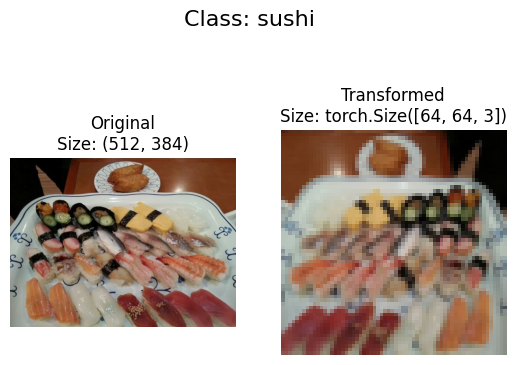

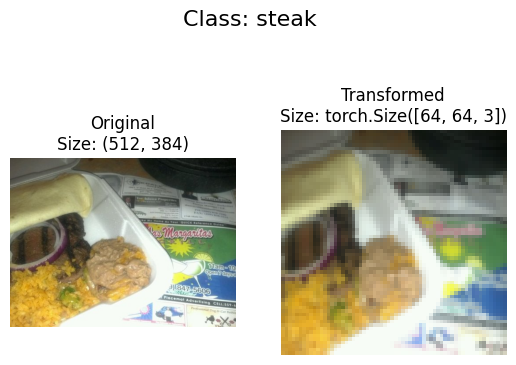

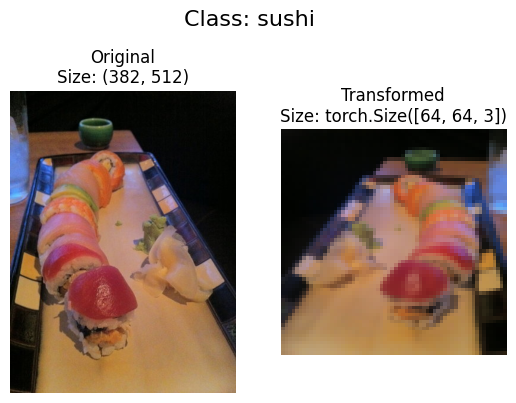

In [13]:
def plot_transform(image_path: list,
                   transform,
                   n=3,
                   seed=None):
    """Selects a random image & loads/transforms it before plotting it against the original."""
    if seed:
        random.seed(seed)
    
    random_image_path = random.sample(image_path, k=n)
    for image_path in random_image_path:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize: {f.size}")
            ax[0].axis(False)

            # Transform & plot target image
            transformed_image = transform(f).permute(1,2,0)  # permute to change from (C, H, W) to (H, W, C) for plotting
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\nSize: {transformed_image.shape}")
            ax[1].axis(False)

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transform(image_path = image_path_list,
               transform = data_transform,
               n = 3,
               seed = 1337)

## 4. Option 1: Loading image data using `ImageFolder`.

We can load image classification data using `torchvision.datasets.ImageFolder`

In [14]:
# Use ImageFolder to create dataset(s)
from torchvision import datasets

train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform, # transform is used to transform the data
                                  target_transform=None) # target_transform is used to transform the target data (e.g. labels)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data\pizza_steak_sushi_10.0_percent\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data\pizza_steak_sushi_10.0_percent\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [15]:
# Get class names as a list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [16]:
# Get class names as a dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [17]:
# Check length of datasets
len(train_data), len(test_data)

(225, 75)

In [19]:
train_data.samples[:10]

[('data\\pizza_steak_sushi_10.0_percent\\train\\pizza\\1008844.jpg', 0),
 ('data\\pizza_steak_sushi_10.0_percent\\train\\pizza\\1033251.jpg', 0),
 ('data\\pizza_steak_sushi_10.0_percent\\train\\pizza\\1044789.jpg', 0),
 ('data\\pizza_steak_sushi_10.0_percent\\train\\pizza\\1089334.jpg', 0),
 ('data\\pizza_steak_sushi_10.0_percent\\train\\pizza\\1105700.jpg', 0),
 ('data\\pizza_steak_sushi_10.0_percent\\train\\pizza\\12301.jpg', 0),
 ('data\\pizza_steak_sushi_10.0_percent\\train\\pizza\\1285298.jpg', 0),
 ('data\\pizza_steak_sushi_10.0_percent\\train\\pizza\\138855.jpg', 0),
 ('data\\pizza_steak_sushi_10.0_percent\\train\\pizza\\1412034.jpg', 0),
 ('data\\pizza_steak_sushi_10.0_percent\\train\\pizza\\1524655.jpg', 0)]

In [37]:
# Index on the train_data dataset to get a single image & label. Remember, first index is the image, second index is the label.
img = train_data[0][0] # Get the first image in the dataset
label = train_data[0][1] # Get the label of the first image in the dataset

#img, label

# Get info about the dat
print(f"Image tensor: \n{img}\n")
print(f"Image shape: \n{img.shape}\n")
print(f"Img dtype: \n{img.dtype}\n")
print(f"Label: \n{label}\n")
print(f"Label type: \n{type(label)}\n") # .dtype is only available for numpy arrays & tensors, an int requires type()

Image tensor: 
tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.0

### 4.1 Plot with matplotlib

To plot, we first must rearage the image shape, as PyTorch does [C, H, W], however matplotlib does [H, W, C]

Original Shape: torch.Size([3, 64, 64])
Permuted Shape: torch.Size([64, 64, 3])


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

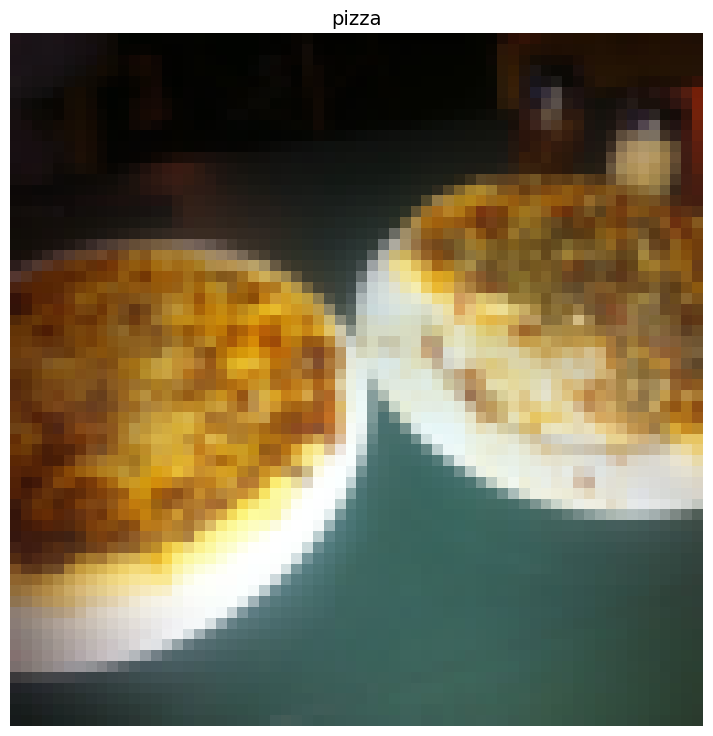

In [99]:
# Rearange the order dimensions
img_perm = img.permute(1, 2, 0)
print(f"Original Shape: {img.shape}")
print(f"Permuted Shape: {img_perm.shape}")

# Plot the image
plt.figure(figsize=(9,9))
plt.imshow(img_perm)
plt.title(class_names[label], fontsize=14)
plt.axis(False)


## 4.1 Turn loaded imaages into `DataLoader`'s

A `DataLoader` will help turn our `Dataset`'s into iterables. We can customize the `batch_size` so the model can see `batch_size` images at a time.

In [ ]:
os.cpu_count() # Returns the number of CPU cores available on the machine

20

In [110]:
# Create train & test dataloaders

BATCH_SIZE = 1
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=4,  # how many CPU cores to use for loading data.
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=4,
                             shuffle=False)


In [113]:
# len(DataLoader)/batch_size
len(train_dataloader), len(test_dataloader)

(225, 75)

In [122]:
img, label = next(iter(train_dataloader))

print(f"Image Shape: {img.shape} -> [batch_size, color_channels, height, width]") 
print(f"Label Shape: {label.shape} -> [batch_size]") # label is a tensor of shape (batch_size) where batch_size is 1 in this case

Image Shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label Shape: torch.Size([1]) -> [batch_size]


## 5. Option 2: Loading image Data with a custom `Dataset` class

1. Want to be able to load images from file.
2. Want to be able to get class names from the Dataset.
3. Want to be able to get classes as a dictionary from the Dataset.

**Pros:**
* Can create a `Dataset` out of almost anything/
* Not limited to PyTorch pre-built `Dataset` functions.

**Cons:**
* Even though you could create a `Dataset` out of almost anything, it is not guaranteed to work.
* Using a custom `Dataset` requires writing more code, which is opens the door for more errors & performance issues. At least compared to a rigurously tested official PyTorch method.

In [123]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [124]:
# Instance of torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.1 Creating a helper function to get class names

Create a function that:
1. Gets the class names using `os.scandir()` to travere a target directorty (ideally the directory is in standard image classification format).
2. Raise an error if the class names aren't found (if this occurs, there might be an error with the directory structure).
3. Turn the class names into a dict & a list & return them.

In [140]:
# Setup path for target directory
target_dir = pathlib.Path("data/pizza_steak_sushi_10.0_percent/train") # train_dir
print(f"Target directory: {target_dir}")

# Get the class names frin the target directory
class_names_found = sorted([entry.name for entry in list(os.scandir(target_dir))]) # returns a list of class names found in the target directory in alphabetical order
class_names_found

Target directory: data\pizza_steak_sushi_10.0_percent\train


['pizza', 'steak', 'sushi']

In [ ]:
def find_class(directory: str) -> Tuple[List[str], Dict[str, int]]:
    """Finds the class folder names in a target directory. Returns a list & a dictionary."""
    # 1. Get the class names by scanning the target directory
    classes = sorted([entry.name for entry in os.scandir(target_dir) if entry.is_dir()])
    
    # 2. Raise an error if class names could not be found.
    if not classes:
        raise FileNotFoundError(f"Could not find any classes in {directory}... Check the directory structure.")
    
    # 3. Create a dictionary of index labels.
    class_to_idx = {class_name: i for i, class_name in enumerate(classes)} # 
    return classes, class_to_idx

In [144]:
find_class(target_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.2 Create a custom `Dataset` to replicate `ImageFolder`

To create our own custom dataset, we want to:
1. Subclass `torch.utils.data.Dataset`
2. Init our subclass with a target directory (the directory we would like to get data from) as well as a transform if we would like to transform our data.
3. Create several attributes:
* paths - paths of our images.
* transform - the transform we would like to use.
* classes - a list of the target classes.
* class_to_idx - a dict of the target classes mapped to integer labels.
4. Create a function to `load_images()`, this function will open an image.
5. Overwrite the `__len()__` method to return the length of our dataset.
6. Overwrite the `__getitem()` method to return a given sample when passed an index.